In [1]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import os
import re
import time
import matplotlib
import sys
import pandas as pd

sys.path.append('../')
from carpet_reconstruction import GetCarpetSignal, VEM, get_rho, NKG, num_sort, get_xy, get_angles, inout_mean_checker
from matplotlib.backends.backend_pdf import PdfPages

from lmfit import Model, Parameters

In [2]:
plt.rcParams['figure.dpi'] = 200

In [3]:
gmodel = Model(NKG)
gmodel.set_param_hint('s', min=0.4, max=1.8)
gmodel.set_param_hint('Ne', min=10, max=1e8)

In [4]:
print(gmodel.param_names, gmodel.independent_vars)

['s', 'Ne'] ['x']


In [55]:
path = '../Data/iron_roof/'

filenames = [path + filename for filename in os.listdir(path)]
filenames.sort(key=num_sort)

In [56]:
all_data = pd.read_csv('../iron_28k_roof.csv')

In [57]:
Ne_true = np.array(all_data['Ne'], dtype=int)

In [58]:
E_arr = []
theta_true_arr = []
theta_rec_arr = []
phi_true_arr = []
phi_rec_arr = []
Ne_true_arr = []
Ne_rec_arr = []
Ne_err_arr = []
N_mu = []
s_rec_arr = []
s_err_arr = []
x_rec_arr = []
y_rec_arr = []
Chi_sq_arr = []
E_trig = []

for filename in filenames:

    print(filename)
    
    file = uproot.open(filename)
    
    names = np.array(file.keys())
    times = names[:len(names) // 3]
    cover_hists = names[len(names) // 3::2]
    muon_hists = names[len(names) // 3 + 1::2]

    cover_signals = np.zeros((len(cover_hists), 20, 20))
    
    for i, hist in enumerate(cover_hists):
        cov_hist = np.copy(np.flip(file[hist].values().T, 0))
        cover_signals[i] = VEM(GetCarpetSignal(cov_hist))

    muon_summ = np.zeros(len(muon_hists))

    for i, muon_hist in enumerate(muon_hists):
        muon_summ[i] = file[muon_hist].values().sum()
        
    time_array = np.zeros((len(times), 4))
    
    for i, t in enumerate(times):
        time_array[i] = file[t]['t_ns'].array(library='np')[1:5]

    for i in range(len(cover_signals)):
    
        sig = cover_signals[i]
        times = time_array[i]

        if (np.all(times) and (np.sum(sig) > 15)):
            
            E_trig.append(float(cover_hists[i].split('_')[0]))
        
        if (inout_mean_checker(sig) and (np.all(times)) and (np.count_nonzero(sig) > 50)):

            x_rec, y_rec = get_xy(sig)
            theta_rec, phi_rec = get_angles(times)

            if (np.abs(x_rec) < 12.6) and (np.abs(y_rec) < 12.6) and (theta_rec < np.radians(40)):

                E_true = float(cover_hists[i].split('_')[0])
                theta_true = float(cover_hists[i].split('_')[1])
                phi_true = float(cover_hists[i].split('_')[2])
            
                r, rho = get_rho(sig, angles=np.array([phi_rec, theta_rec]))
            
                result = gmodel.fit(rho, x=r)
            
                Ne_rec = result.params['Ne'].value
                Ne_err = result.params['Ne'].stderr
                s_rec = result.params['s'].value
                s_err = result.params['s'].stderr
                Chi_sq = result.chisqr

                E_arr.append(E_true)
                theta_true_arr.append(theta_true)
                theta_rec_arr.append(np.degrees(theta_rec))
                phi_true_arr.append(phi_true)
                phi_rec_arr.append(np.degrees(phi_rec))
                Ne_true_arr.append(Ne_true[i])
                Ne_rec_arr.append(Ne_rec)
                Ne_err_arr.append(Ne_err)
                N_mu.append(muon_summ[i])
                s_rec_arr.append(s_rec)
                s_err_arr.append(s_err)
                x_rec_arr.append(x_rec)
                y_rec_arr.append(y_rec)
                Chi_sq_arr.append(Chi_sq)

print('fin')

../Data/iron_roof/output0.root
../Data/iron_roof/output1.root
../Data/iron_roof/output2.root
../Data/iron_roof/output3.root
../Data/iron_roof/output4.root
../Data/iron_roof/output5.root
../Data/iron_roof/output6.root
../Data/iron_roof/output7.root
../Data/iron_roof/output8.root
../Data/iron_roof/output9.root
../Data/iron_roof/output10.root
../Data/iron_roof/output11.root
../Data/iron_roof/output12.root
../Data/iron_roof/output13.root
../Data/iron_roof/output14.root
../Data/iron_roof/output15.root
../Data/iron_roof/output16.root
../Data/iron_roof/output17.root
../Data/iron_roof/output18.root
../Data/iron_roof/output19.root
../Data/iron_roof/output20.root
../Data/iron_roof/output21.root
../Data/iron_roof/output22.root
../Data/iron_roof/output23.root
../Data/iron_roof/output24.root
../Data/iron_roof/output25.root
../Data/iron_roof/output26.root
../Data/iron_roof/output27.root
../Data/iron_roof/output28.root
fin


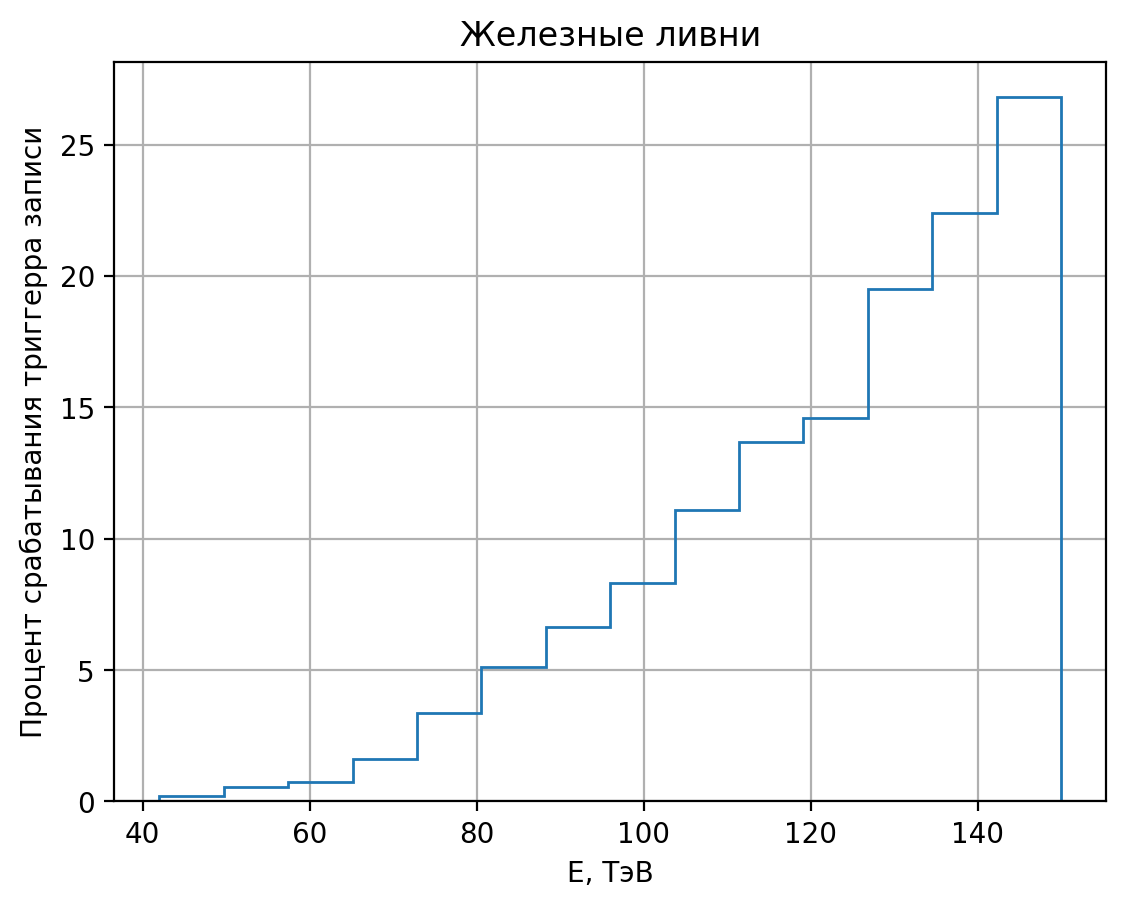

In [60]:
plt.hist(E_trig, histtype='step', bins=14, weights = np.hstack((np.ones(len(E_trig)-1)/20, 1/22)))

plt.xlabel('E, ТэВ')
plt.ylabel('Процент срабатывания триггерра записи')

plt.title('Железные ливни')

plt.grid()

plt.savefig('iron_record_trigger.png')

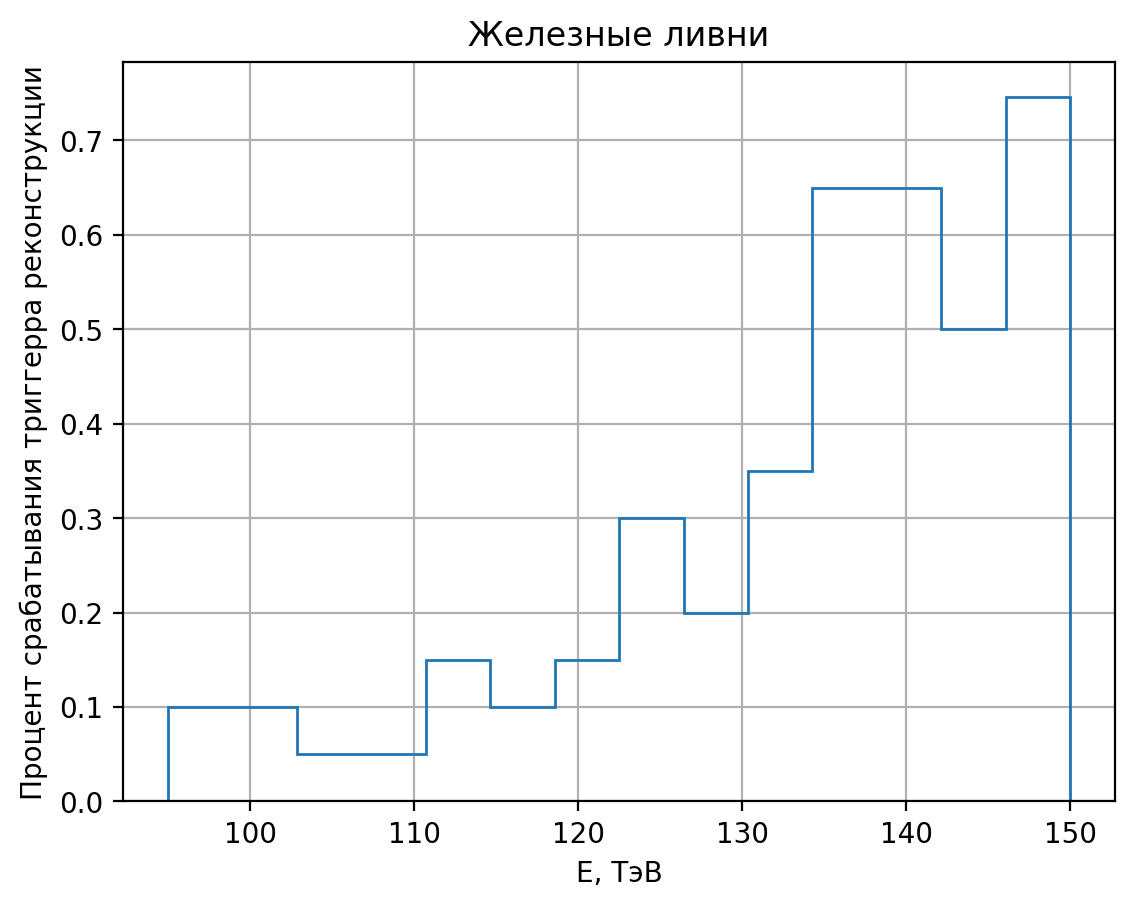

In [59]:
plt.hist(E_arr, histtype='step', bins=14, weights = np.hstack((np.ones(len(E_arr)-1)/20, 1/22)))

plt.xlabel('E, ТэВ')
plt.ylabel('Процент срабатывания триггерра реконструкции')

plt.title('Железные ливни')

plt.grid()

plt.savefig('iron_reconstruction_trigger.png')

In [21]:
d = {'E': E_arr, 'theta_true': theta_true_arr, 'theta_rec': theta_rec_arr, 'phi_true': phi_true_arr, 'phi_rec': phi_rec_arr, 'Ne_true': Ne_true_arr, 
     'Ne_rec': Ne_rec_arr, 'Ne_err': Ne_err_arr, 'N_mu': N_mu, 's_rec': s_rec_arr, 's_err': s_err_arr, 'x_rec': x_rec_arr, 'y_rec': y_rec_arr, 'Chi_sq': Chi_sq_arr}
ReconstructionData = pd.DataFrame(d)
ReconstructionData

,E,theta_true,theta_rec,phi_true,phi_rec,Ne_true,Ne_rec,Ne_err,N_mu,s_rec,s_err,x_rec,y_rec,Chi_sq
0,13.0,19.44990,24.191334,-170.97600,147.657591,46623,15221.261620,2023.420822,0.0,0.911731,0.025586,-0.589671,-3.626048,3.235742e+04
1,13.0,15.99100,21.592615,55.40430,337.996015,47940,207578.812836,49186.599046,0.0,1.541773,0.040322,2.504577,1.723134,5.088122e+04
2,13.0,7.09744,22.598383,-72.57880,124.983442,78562,34770.044039,16645.636019,0.0,1.041088,0.265570,-0.942936,0.180832,7.385683e+04
3,14.0,15.04460,15.022520,179.35300,229.142324,58230,42184.193801,19284.666700,0.0,1.156011,0.202847,-0.402828,-2.590924,4.940771e+04
4,14.0,5.83809,10.228790,175.95000,155.928513,107570,131143.221178,9335.895536,0.0,1.104373,0.008820,0.235045,-1.057570,1.290369e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6749,150.0,27.37450,27.537389,-137.96500,207.682382,5014,418070.689824,179990.539040,0.0,1.800000,0.001088,-3.857790,-4.242842,3.601024e+03
6750,150.0,16.04460,12.968412,-5.11778,50.930640,751,133596.552041,4431.513749,0.0,1.320694,0.001426,-0.305974,2.575167,2.188768e+05
6751,150.0,18.45820,24.565611,-79.44380,269.745114,1651,99366.833428,31512.350784,0.0,1.245019,0.209220,-3.257253,0.437433,1.405953e+05
6752,150.0,12.29430,37.296182,65.39890,88.723679,5307,120556.046105,13272.768851,0.0,1.435285,0.023886,1.814003,1.195979,5.453740e+04


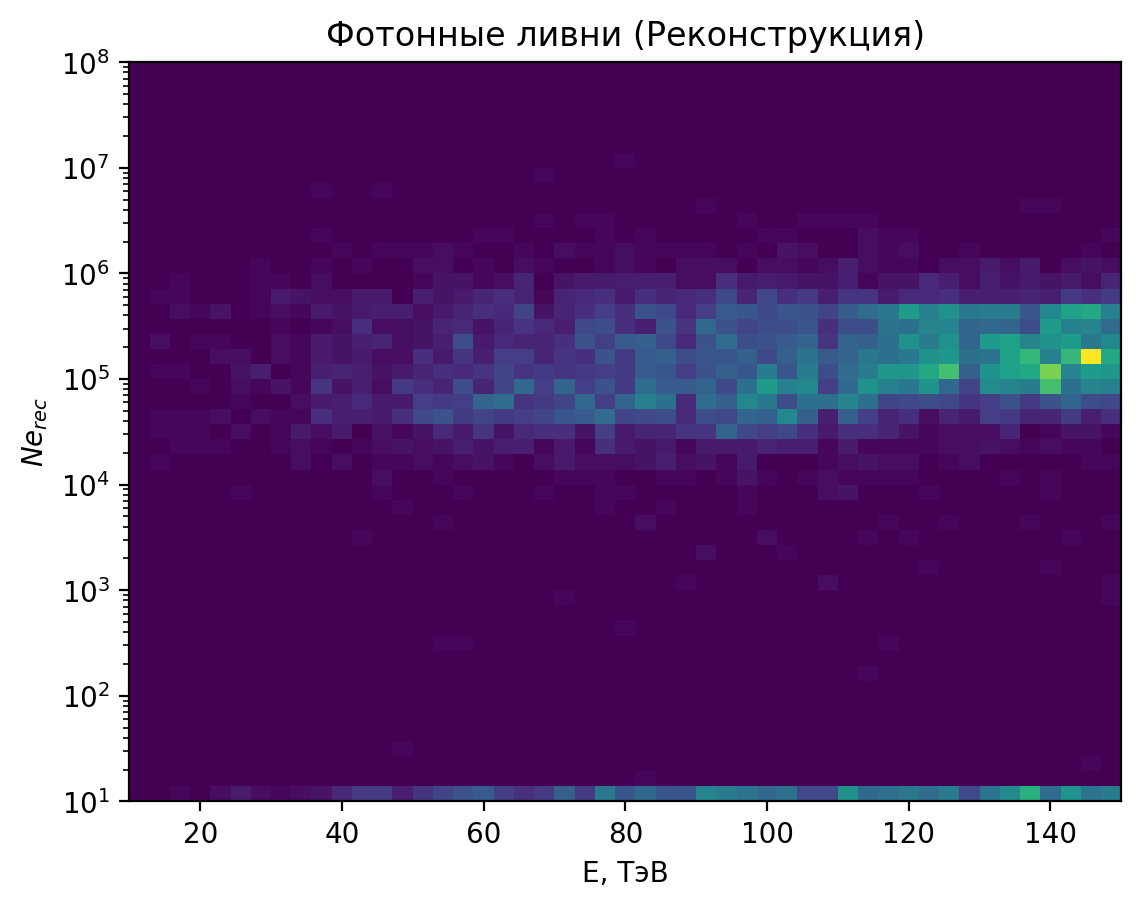

In [47]:
xbins = np.linspace(10, 150, 50)
ybins = 10**np.linspace(1, 8, 50)

plt.hist2d(ReconstructionData['E'], ReconstructionData['Ne_rec'], bins=(xbins, ybins))
# plt.scatter(ReconstructionData['E'], ReconstructionData['Ne_rec'], s=0.1)

plt.yscale('log')

plt.xlabel('E, ТэВ')
plt.ylabel('$Ne_{rec}$')

plt.title('Фотонные ливни (Реконструкция)')

plt.savefig('photon_ne_rec.png')

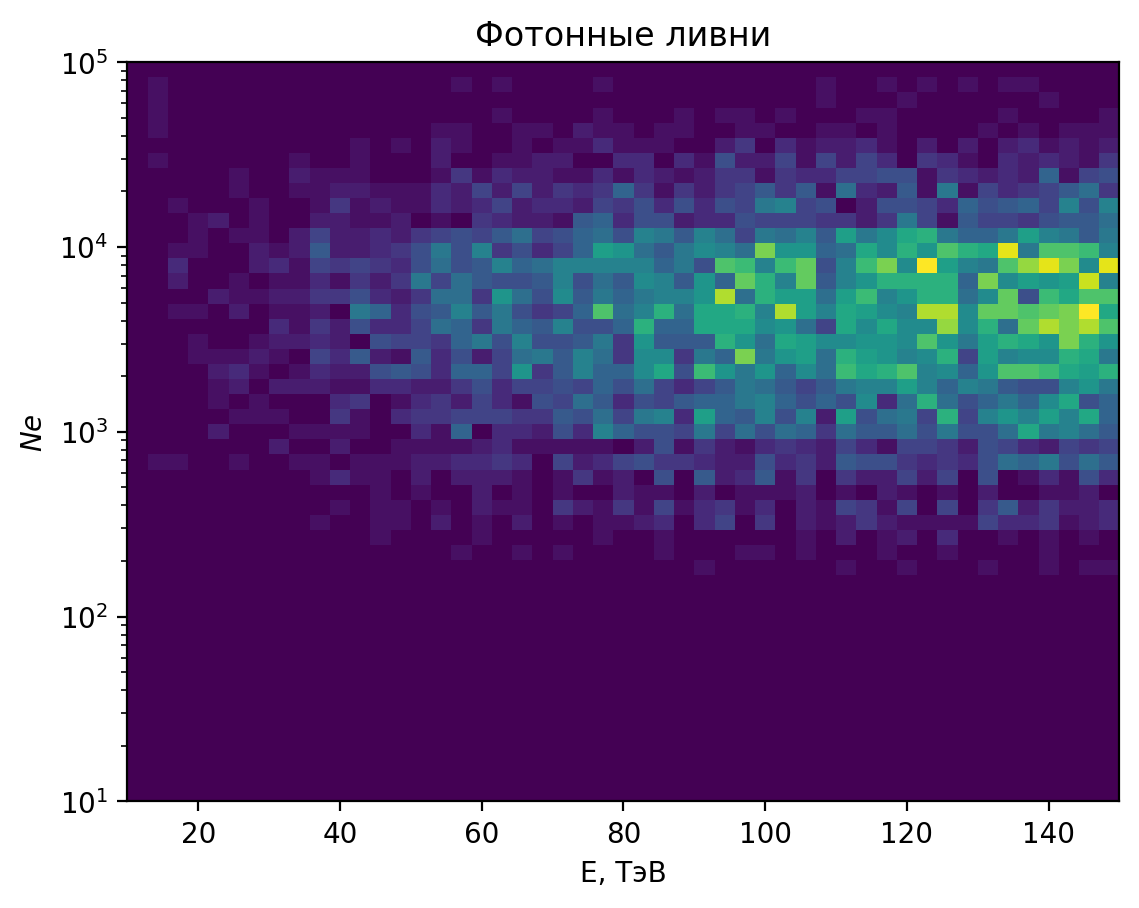

In [46]:
xbins = np.linspace(10, 150, 50)
ybins = 10**np.linspace(1, 5, 50)

plt.hist2d(ReconstructionData['E'], ReconstructionData['Ne_true'], bins=(xbins, ybins))

plt.yscale('log')

plt.xlabel('E, ТэВ')
plt.ylabel('$Ne$')

plt.title('Фотонные ливни')

plt.savefig('photon_ne_true.png')

Text(0.5, 1.0, 'Фотонные ливни')

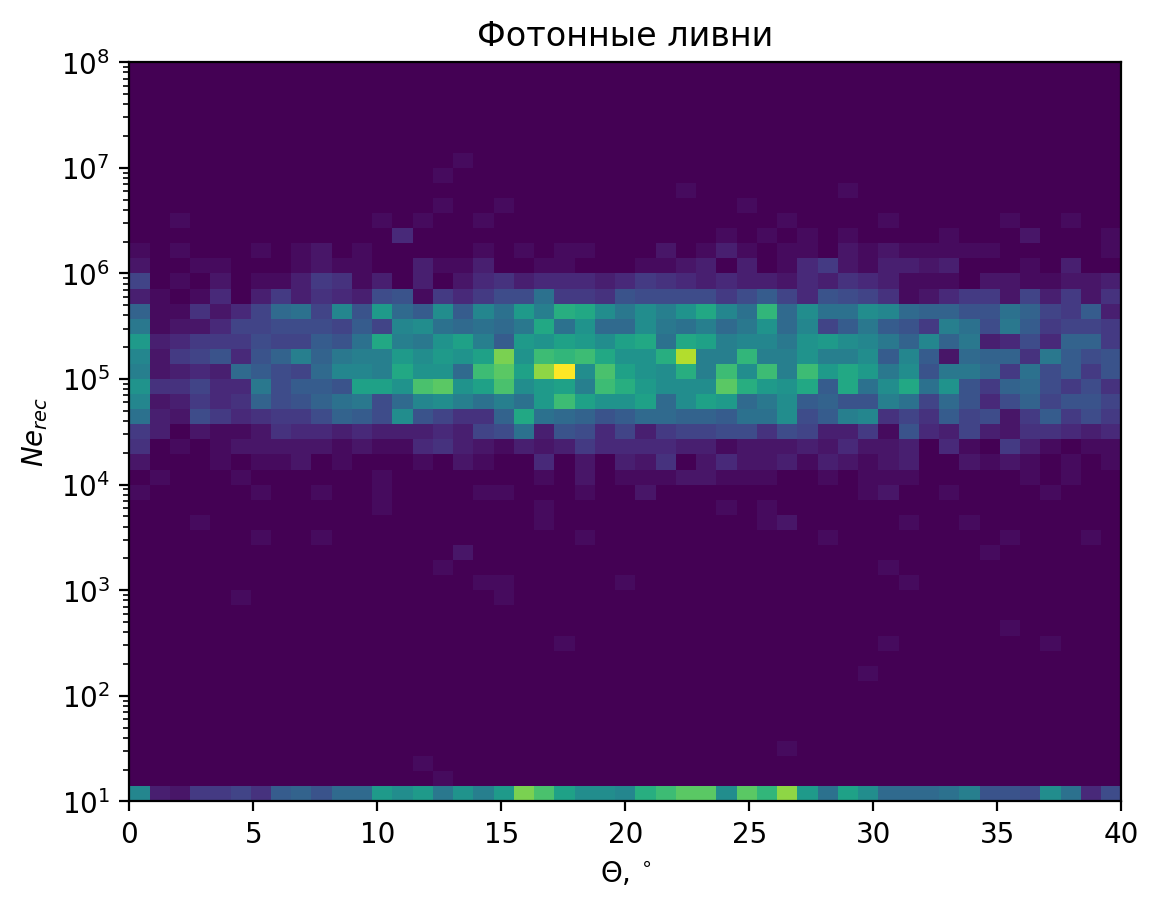

In [39]:
xbins = np.linspace(0, 40, 50)
ybins = 10**np.linspace(1, 8, 50)

plt.hist2d(ReconstructionData['theta_rec'], ReconstructionData['Ne_rec'], bins=(xbins, ybins))

plt.yscale('log')

plt.xlabel('$\Theta, ^\circ$')
plt.ylabel('$Ne_{rec}$')

plt.title('Фотонные ливни')

Text(0.5, 1.0, 'Фотонные ливни')

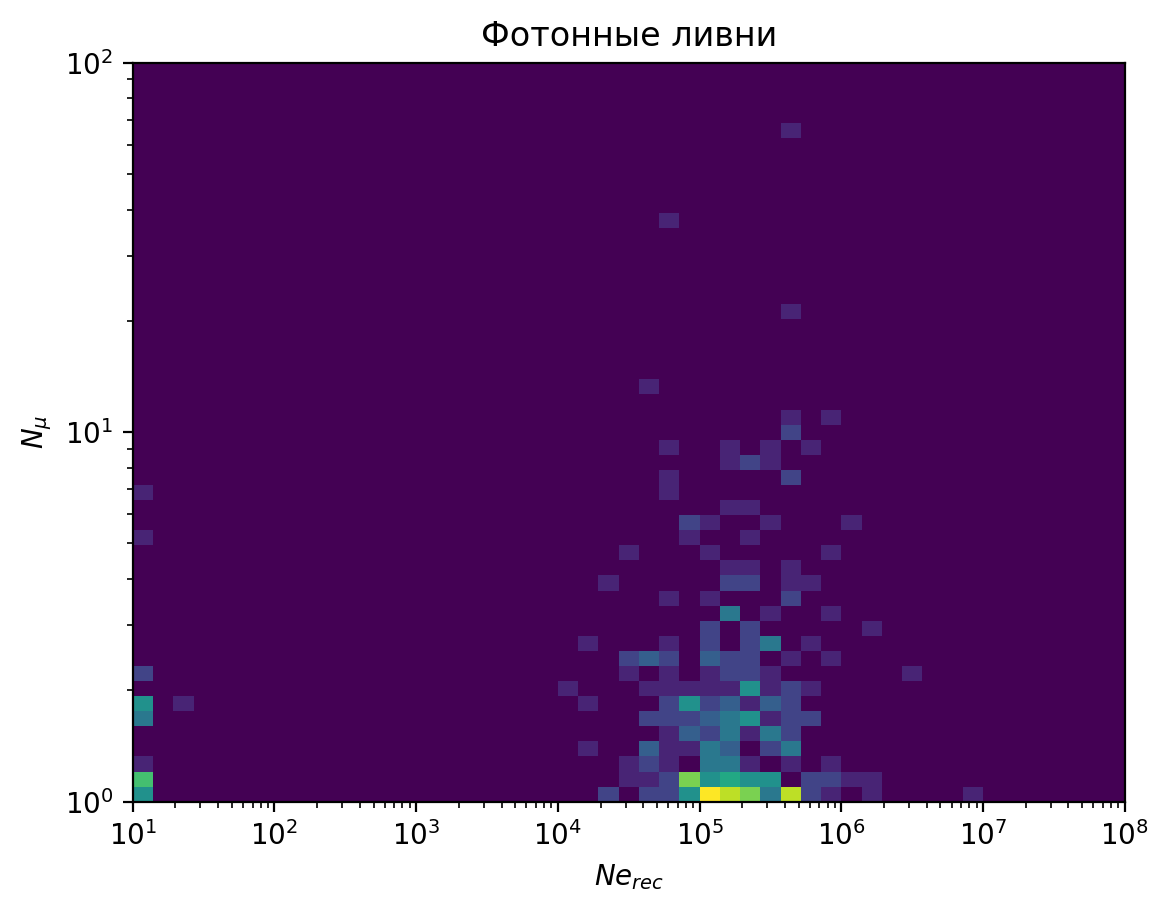

In [41]:
xbins = 10**np.linspace(1, 8, 50)
ybins = 10**np.linspace(0, 2, 50)

plt.hist2d(ReconstructionData['Ne_rec'], ReconstructionData['N_mu'], bins=(xbins, ybins))

plt.yscale('log')
plt.xscale('log')

plt.ylabel('$N_\mu$')
plt.xlabel('$Ne_{rec}$')

plt.title('Фотонные ливни')